# 03 — HCP ROI Time-Series Extraction

This notebook converts one HCP task-fMRI run into regional time series suitable for GRU and Transformer models.

## Pipeline

```text
HCP minimally preprocessed 4D NIfTI
    ↓
NIfTI and motion-regressor QC
    ↓
Schaefer-300 cortical atlas
    ↓
ROI extraction
    ↓
two preprocessing variants
    1. minimal: detrend + standardize
    2. motion-cleaned: detrend + motion regression + standardize
    ↓
QC comparisons
    ↓
save arrays, labels, metadata, and run-level summary
```

This notebook processes one subject, one task, and one run first. The HCP file is already minimally preprocessed; this notebook does not repeat motion correction, distortion correction, registration, or spatial normalization.


In [1]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
from nilearn.datasets import fetch_atlas_schaefer_2018
from nilearn.maskers import NiftiLabelsMasker

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 140)

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("NiBabel:", nib.__version__)

Matplotlib is building the font cache; this may take a moment.


NumPy: 2.4.6
Pandas: 3.0.5
NiBabel: 5.4.2


## 1. Resolve project paths

In [2]:
def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "environment.yml").exists() or (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not locate the NeuroLens repository root.")

PROJECT_ROOT = find_project_root()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw" / "hcp_ya_s1200"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed" / "hcp_ya_s1200" / "roi_timeseries"
CACHE_DIR = PROJECT_ROOT / ".cache" / "nilearn"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data:", RAW_DATA_DIR)
print("Processed data:", PROCESSED_DATA_DIR)
print("Nilearn cache:", CACHE_DIR)

Project root: /Users/srinivasgovindasurampudi/Projects/neurolens-rag
Raw data: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/raw/hcp_ya_s1200
Processed data: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/processed/hcp_ya_s1200/roi_timeseries
Nilearn cache: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/.cache/nilearn


## 2. Run configuration

In [3]:
DATASET_RELEASE = "HCP-YA-S1200"

SUBJECT_ID = "100307"
TASK = "MOTOR"
RUN = "LR"

ATLAS_N_ROIS = 300
ATLAS_NETWORKS = 7
ATLAS_RESOLUTION_MM = 2

DETREND = True
STANDARDIZE = "zscore_sample"
STANDARDIZE_CONFOUNDS = True
LOW_PASS_HZ = None
HIGH_PASS_HZ = None

N_ROIS_TO_PLOT = 10
RANDOM_SEED = 42

run_name = f"tfMRI_{TASK}_{RUN}"
run_dir = RAW_DATA_DIR / SUBJECT_ID / "MNINonLinear" / "Results" / run_name
func_path = run_dir / f"{run_name}.nii.gz"
movement_path = run_dir / "Movement_Regressors.txt"
movement_dt_path = run_dir / "Movement_Regressors_dt.txt"
events_dir = run_dir / "EVs"
output_dir = PROCESSED_DATA_DIR / f"sub-{SUBJECT_ID}" / run_name
output_dir.mkdir(parents=True, exist_ok=True)

print("Run directory:", run_dir)
print("Functional NIfTI:", func_path)
print("Movement regressors:", movement_path)
print("Events directory:", events_dir)
print("Output directory:", output_dir)

Run directory: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/raw/hcp_ya_s1200/100307/MNINonLinear/Results/tfMRI_MOTOR_LR
Functional NIfTI: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/raw/hcp_ya_s1200/100307/MNINonLinear/Results/tfMRI_MOTOR_LR/tfMRI_MOTOR_LR.nii.gz
Movement regressors: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/raw/hcp_ya_s1200/100307/MNINonLinear/Results/tfMRI_MOTOR_LR/Movement_Regressors.txt
Events directory: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/raw/hcp_ya_s1200/100307/MNINonLinear/Results/tfMRI_MOTOR_LR/EVs
Output directory: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/processed/hcp_ya_s1200/roi_timeseries/sub-100307/tfMRI_MOTOR_LR


## 3. Validate required local files

In [4]:
required_paths = {
    "functional_nifti": func_path,
    "movement_regressors": movement_path,
}
missing_paths = {name: path for name, path in required_paths.items() if not path.exists()}
if missing_paths:
    formatted = "\n".join(f"- {name}: {path}" for name, path in missing_paths.items())
    raise FileNotFoundError(f"Required files are missing:\n{formatted}")

print("Required files found.")
print("Derivative regressors found:", movement_dt_path.exists())
print("Events directory found:", events_dir.exists())
if events_dir.exists():
    print("Event files:", len(list(events_dir.glob("*.txt"))))

Required files found.
Derivative regressors found: True
Events directory found: True
Event files: 7


## 4. Inspect the 4D NIfTI lazily

In [5]:
img = nib.load(func_path)
if len(img.shape) != 4:
    raise ValueError(f"Expected 4D fMRI, got {img.shape}.")

n_x, n_y, n_z, n_timepoints = img.shape
zooms = img.header.get_zooms()
voxel_sizes = tuple(float(v) for v in zooms[:3])
tr_seconds = float(zooms[3])

nifti_qc = {
    "shape": tuple(int(v) for v in img.shape),
    "n_timepoints": int(n_timepoints),
    "voxel_sizes_mm": voxel_sizes,
    "tr_seconds": tr_seconds,
    "dtype": str(img.get_data_dtype()),
    "affine_is_finite": bool(np.isfinite(img.affine).all()),
    "header_units": tuple(str(v) for v in img.header.get_xyzt_units()),
}
print(json.dumps(nifti_qc, indent=2))

if not nifti_qc["affine_is_finite"]:
    raise ValueError("NIfTI affine contains non-finite values.")

{
  "shape": [
    91,
    109,
    91,
    284
  ],
  "n_timepoints": 284,
  "voxel_sizes_mm": [
    2.0,
    2.0,
    2.0
  ],
  "tr_seconds": 0.7200000286102295,
  "dtype": "float32",
  "affine_is_finite": true,
  "header_units": [
    "mm",
    "sec"
  ]
}


## 5. Inspect motion regressors

In [6]:
movement = np.loadtxt(movement_path)
if movement.ndim == 1:
    movement = movement[:, None]

print("Movement-regressor shape:", movement.shape)
print("NIfTI time points:", n_timepoints)

if movement.shape[0] != n_timepoints:
    raise ValueError(
        f"Movement regressors and NIfTI differ in time points: {movement.shape[0]} vs {n_timepoints}."
    )
if not np.isfinite(movement).all():
    raise ValueError("Movement regressors contain non-finite values.")

movement_summary = pd.DataFrame({
    "column": np.arange(movement.shape[1]),
    "mean": movement.mean(axis=0),
    "std": movement.std(axis=0),
    "min": movement.min(axis=0),
    "max": movement.max(axis=0),
})
movement_summary.head(20)

Movement-regressor shape: (284, 12)
NIfTI time points: 284


,column,mean,std,min,max
0,0,-0.029268,0.055623,-0.173558,0.111509
1,1,0.109480,0.011025,0.082650,0.140092
2,2,0.075051,0.029320,-0.012989,0.187460
3,3,-0.291225,0.117977,-0.586766,0.000000
4,4,-0.010141,0.027938,-0.073052,0.071677
5,5,0.079343,0.052825,-0.048587,0.193316
6,6,0.000219,0.062388,-0.129410,0.139194
7,7,0.000080,0.010693,-0.026155,0.025814
8,8,0.000121,0.025014,-0.074995,0.092463
9,9,-0.001424,0.055425,-0.209187,0.188217


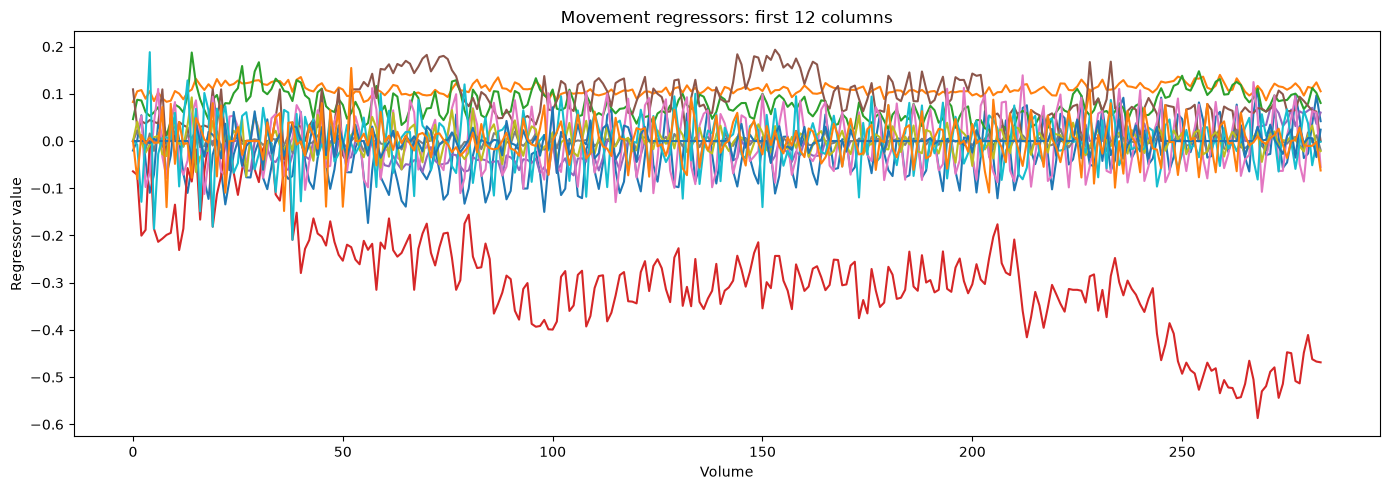

In [7]:
n_motion_columns_to_plot = min(12, movement.shape[1])
plt.figure(figsize=(14, 5))
plt.plot(movement[:, :n_motion_columns_to_plot])
plt.xlabel("Volume")
plt.ylabel("Regressor value")
plt.title(f"Movement regressors: first {n_motion_columns_to_plot} columns")
plt.tight_layout()
plt.show()

## 6. Inspect optional derivative regressors

In [8]:
movement_dt = None
if movement_dt_path.exists():
    movement_dt = np.loadtxt(movement_dt_path)
    if movement_dt.ndim == 1:
        movement_dt = movement_dt[:, None]
    print("Derivative-regressor shape:", movement_dt.shape)
    if movement_dt.shape[0] != n_timepoints:
        raise ValueError("Derivative regressors and NIfTI differ in time points.")
else:
    print("Derivative regressors not available; continuing.")

Derivative-regressor shape: (284, 12)


## 7. Fetch the Schaefer atlas

In [9]:
atlas = fetch_atlas_schaefer_2018(
    n_rois=ATLAS_N_ROIS,
    yeo_networks=ATLAS_NETWORKS,
    resolution_mm=ATLAS_RESOLUTION_MM,
)
atlas_path = Path(atlas.maps)
raw_atlas_labels = [
    label.decode("utf-8") if isinstance(label, bytes) else str(label)
    for label in atlas.labels
]
print("Atlas path:", atlas_path)
print("Raw label count:", len(raw_atlas_labels))
print("First labels:", raw_atlas_labels[:5])

[fetch_atlas_schaefer_2018] Added README.md to /Users/srinivasgovindasurampudi/nilearn_data

[fetch_atlas_schaefer_2018] Dataset created in /Users/srinivasgovindasurampudi/nilearn_data/schaefer_2018

[fetch_atlas_schaefer_2018] Downloading data from 
https://raw.githubusercontent.com/ThomasYeoLab/CBIG/v0.14.3-Update_Yeo2011_Schaefer2018_labelname/stable_projects/b
rain_parcellation/Schaefer2018_LocalGlobal/Parcellations/MNI/Schaefer2018_300Parcels_7Networks_order.txt ...

[fetch_atlas_schaefer_2018]  ...done. (0 seconds, 0 min)

[fetch_atlas_schaefer_2018] Downloading data from 
https://raw.githubusercontent.com/ThomasYeoLab/CBIG/v0.14.3-Update_Yeo2011_Schaefer2018_labelname/stable_projects/b
rain_parcellation/Schaefer2018_LocalGlobal/Parcellations/MNI/Schaefer2018_300Parcels_7Networks_order_FSLMNI152_2mm.
nii.gz ...

[fetch_atlas_schaefer_2018]  ...done. (0 seconds, 0 min)

Atlas path: /Users/srinivasgovindasurampudi/nilearn_data/schaefer_2018/Schaefer2018_300Parcels_7Networks_order_FSLMNI152_2mm.nii.gz
Raw label count: 301
First labels: ['Background', '7Networks_LH_Vis_1', '7Networks_LH_Vis_2', '7Networks_LH_Vis_3', '7Networks_LH_Vis_4']


## 8. Normalize atlas labels

In [10]:
def normalize_atlas_labels(labels: list[str], expected_roi_count: int) -> list[str]:
    normalized = list(labels)
    if len(normalized) == expected_roi_count + 1:
        normalized = normalized[1:]
    if len(normalized) != expected_roi_count:
        raise ValueError(
            f"Atlas label count {len(normalized)} does not match expected ROI count {expected_roi_count}."
        )
    return normalized

roi_labels = normalize_atlas_labels(raw_atlas_labels, ATLAS_N_ROIS)
print("Normalized label count:", len(roi_labels))
print("First labels:", roi_labels[:5])

Normalized label count: 300
First labels: ['7Networks_LH_Vis_1', '7Networks_LH_Vis_2', '7Networks_LH_Vis_3', '7Networks_LH_Vis_4', '7Networks_LH_Vis_5']


## 9. Build two extraction pipelines

In [11]:
def build_masker(atlas_img: str | Path, atlas_labels: list[str], tr_seconds: float) -> NiftiLabelsMasker:
    return NiftiLabelsMasker(
        labels_img=str(atlas_img),
        labels=atlas_labels,
        background_label=0,
        standardize=STANDARDIZE,
        standardize_confounds=STANDARDIZE_CONFOUNDS,
        detrend=DETREND,
        low_pass=LOW_PASS_HZ,
        high_pass=HIGH_PASS_HZ,
        t_r=tr_seconds,
        resampling_target="data",
        memory=str(CACHE_DIR),
        memory_level=1,
        verbose=1,
    )

minimal_masker = build_masker(atlas_path, roi_labels, tr_seconds)
motion_cleaned_masker = build_masker(atlas_path, roi_labels, tr_seconds)
print(minimal_masker)

NiftiLabelsMasker(detrend=True,
                  labels=['7Networks_LH_Vis_1', '7Networks_LH_Vis_2',
                          '7Networks_LH_Vis_3', '7Networks_LH_Vis_4',
                          '7Networks_LH_Vis_5', '7Networks_LH_Vis_6',
                          '7Networks_LH_Vis_7', '7Networks_LH_Vis_8',
                          '7Networks_LH_Vis_9', '7Networks_LH_Vis_10',
                          '7Networks_LH_Vis_11', '7Networks_LH_Vis_12',
                          '7Networks_LH_Vis_13', '7Networks_LH_Vis_14',
                          '7Networks_L...
                          '7Networks_LH_SomMot_3', '7Networks_LH_SomMot_4',
                          '7Networks_LH_SomMot_5', '7Networks_LH_SomMot_6', ...],
                  labels_img='/Users/srinivasgovindasurampudi/nilearn_data/schaefer_2018/Schaefer2018_300Parcels_7Networks_order_FSLMNI152_2mm.nii.gz',
                  memory='/Users/srinivasgovindasurampudi/Projects/neurolens-rag/.cache/nilearn',
                  stand

## 10. Extract minimally cleaned ROI time series

In [12]:
roi_timeseries_minimal = minimal_masker.fit_transform(str(func_path))
print("Minimal shape:", roi_timeseries_minimal.shape)

[NiftiLabelsMasker.wrapped] Loading regions from 
'/Users/srinivasgovindasurampudi/nilearn_data/schaefer_2018/Schaefer2018_300Parcels_7Networks_order_FSLMNI152_2mm.n
ii.gz'

[NiftiLabelsMasker.wrapped] Finished fit

________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker.filter_and_extract...
filter_and_extract('/Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/raw/hcp_ya_s1200/100307/MNINonLinear/Results/tfMRI_MOTOR_LR/tfMRI_MOTOR_LR.nii.gz', 
<nilearn.maskers.nifti_labels_masker._ExtractionFunctor object at 0x13e803110>, { 'background_label': 0,
  'clean_args': None,
  'clean_kwargs': {},
  'cmap': None,
  'detrend': True,
  'dtype': None,
  'high_pass': None,
  'high_variance_confounds': False,
  'keep_masked_labels': False,
  'labels': [ '7Networks_LH_Vis_1',
              '7Networks_LH_Vis_2',
              '7Networks_LH_Vis_3',
              '7Networks_LH_Vis_4',
              '7Networks_LH_Vis_5',
              '7Networks_LH_Vis_6',
              '7Networks_LH_Vis_7',
              '7Networks_LH_Vis_8',
              '7Networks_LH_Vis_9',
              '7Networks_LH_Vis_10',
              '7Networks_LH_Vis_11',


[NiftiLabelsMasker.wrapped] Loading data from 
'/Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/raw/hcp_ya_s1200/100307/MNINonLinear/Results/tfMRI_MOT
OR_LR/tfMRI_MOTOR_LR.nii.gz'

[NiftiLabelsMasker.wrapped] Extracting region signals

[NiftiLabelsMasker.wrapped] Cleaning extracted signals

______________________________________________filter_and_extract - 10.9s, 0.2min
Minimal shape: (284, 300)


## 11. Extract motion-cleaned ROI time series

In [13]:
roi_timeseries_motion_cleaned = motion_cleaned_masker.fit_transform(
    str(func_path),
    confounds=movement,
)
print("Motion-cleaned shape:", roi_timeseries_motion_cleaned.shape)

[NiftiLabelsMasker.wrapped] Loading regions from 
'/Users/srinivasgovindasurampudi/nilearn_data/schaefer_2018/Schaefer2018_300Parcels_7Networks_order_FSLMNI152_2mm.n
ii.gz'

[NiftiLabelsMasker.wrapped] Finished fit

________________________________________________________________________________
[Memory] Calling nilearn.maskers.base_masker.filter_and_extract...
filter_and_extract('/Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/raw/hcp_ya_s1200/100307/MNINonLinear/Results/tfMRI_MOTOR_LR/tfMRI_MOTOR_LR.nii.gz', 
<nilearn.maskers.nifti_labels_masker._ExtractionFunctor object at 0x13ec02190>, { 'background_label': 0,
  'clean_args': None,
  'clean_kwargs': {},
  'cmap': None,
  'detrend': True,
  'dtype': None,
  'high_pass': None,
  'high_variance_confounds': False,
  'keep_masked_labels': False,
  'labels': [ '7Networks_LH_Vis_1',
              '7Networks_LH_Vis_2',
              '7Networks_LH_Vis_3',
              '7Networks_LH_Vis_4',
              '7Networks_LH_Vis_5',
              '7Networks_LH_Vis_6',
              '7Networks_LH_Vis_7',
              '7Networks_LH_Vis_8',
              '7Networks_LH_Vis_9',
              '7Networks_LH_Vis_10',
              '7Networks_LH_Vis_11',


[NiftiLabelsMasker.wrapped] Loading data from 
'/Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/raw/hcp_ya_s1200/100307/MNINonLinear/Results/tfMRI_MOT
OR_LR/tfMRI_MOTOR_LR.nii.gz'

[NiftiLabelsMasker.wrapped] Extracting region signals

[NiftiLabelsMasker.wrapped] Cleaning extracted signals

______________________________________________filter_and_extract - 10.9s, 0.2min
Motion-cleaned shape: (284, 300)


## 12. Validate extracted arrays

In [14]:
def validate_roi_timeseries(
    array: np.ndarray,
    name: str,
    expected_timepoints: int,
    expected_rois: int,
) -> dict[str, Any]:
    if array.ndim != 2:
        raise ValueError(f"{name} must be 2D, got {array.shape}.")
    if array.shape != (expected_timepoints, expected_rois):
        raise ValueError(
            f"{name} has shape {array.shape}; expected ({expected_timepoints}, {expected_rois})."
        )
    if not np.isfinite(array).all():
        raise ValueError(f"{name} contains non-finite values.")

    roi_means = array.mean(axis=0)
    roi_stds = array.std(axis=0)
    zero_variance_indices = np.where(roi_stds < 1e-8)[0]
    return {
        "name": name,
        "shape": tuple(int(v) for v in array.shape),
        "mean_absolute_roi_mean": float(np.abs(roi_means).mean()),
        "mean_roi_std": float(roi_stds.mean()),
        "minimum_roi_std": float(roi_stds.min()),
        "maximum_roi_std": float(roi_stds.max()),
        "zero_variance_roi_count": int(len(zero_variance_indices)),
        "zero_variance_roi_indices": zero_variance_indices.tolist(),
    }

minimal_qc = validate_roi_timeseries(
    roi_timeseries_minimal, "minimal", n_timepoints, ATLAS_N_ROIS
)
motion_cleaned_qc = validate_roi_timeseries(
    roi_timeseries_motion_cleaned, "motion_cleaned", n_timepoints, ATLAS_N_ROIS
)
pd.DataFrame([minimal_qc, motion_cleaned_qc])

,name,shape,mean_absolute_roi_mean,mean_roi_std,minimum_roi_std,maximum_roi_std,zero_variance_roi_count,zero_variance_roi_indices
0,minimal,"(284, 300)",2.500383e-08,0.998238,0.998237,0.998238,0,[]
1,motion_cleaned,"(284, 300)",1.767160e-08,0.998238,0.998237,0.998239,0,[]


## 13. Plot representative ROI signals

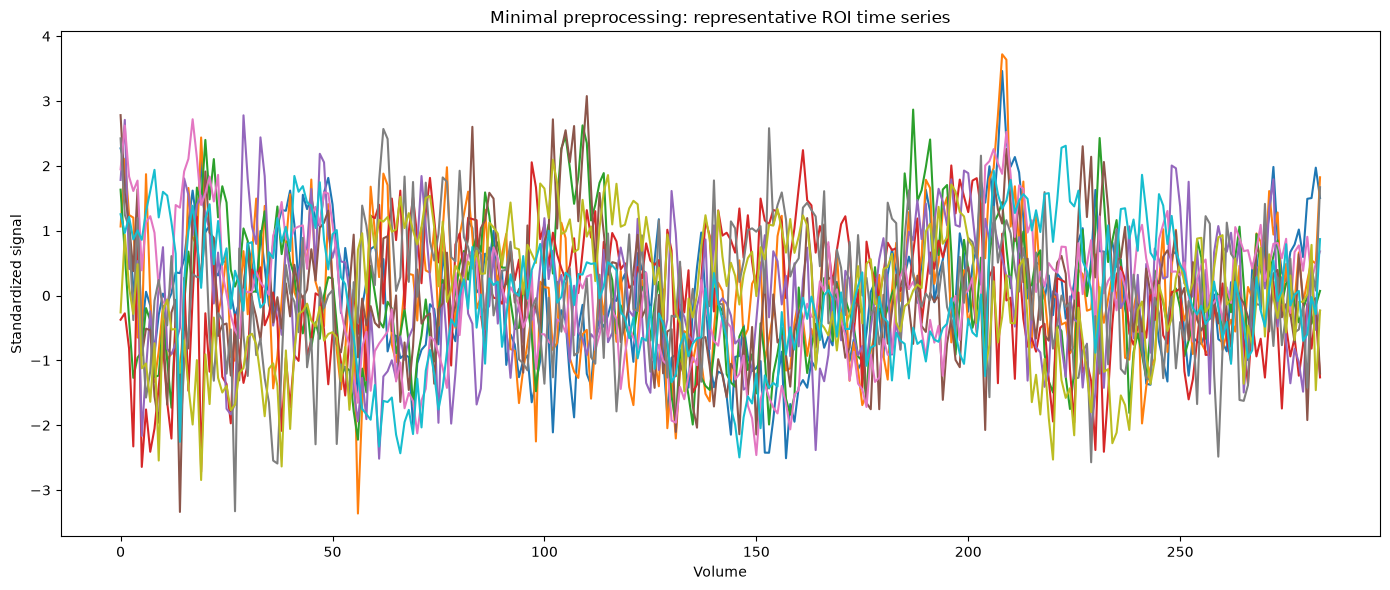

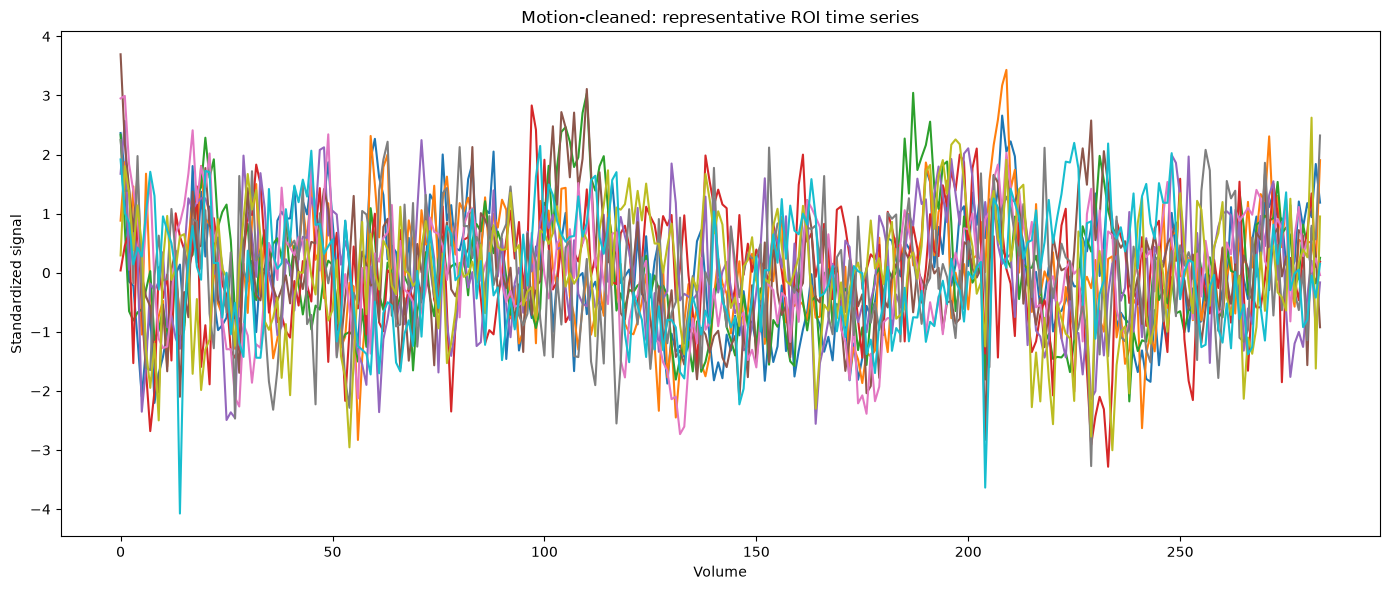

ROI indices: [25, 28, 60, 127, 129, 191, 207, 225, 254, 296]


In [15]:
rng = np.random.default_rng(RANDOM_SEED)
roi_indices_to_plot = np.sort(
    rng.choice(ATLAS_N_ROIS, size=min(N_ROIS_TO_PLOT, ATLAS_N_ROIS), replace=False)
)

plt.figure(figsize=(14, 6))
plt.plot(roi_timeseries_minimal[:, roi_indices_to_plot])
plt.xlabel("Volume")
plt.ylabel("Standardized signal")
plt.title("Minimal preprocessing: representative ROI time series")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
plt.plot(roi_timeseries_motion_cleaned[:, roi_indices_to_plot])
plt.xlabel("Volume")
plt.ylabel("Standardized signal")
plt.title("Motion-cleaned: representative ROI time series")
plt.tight_layout()
plt.show()

print("ROI indices:", roi_indices_to_plot.tolist())

## 14. Compare ROI correlation structure

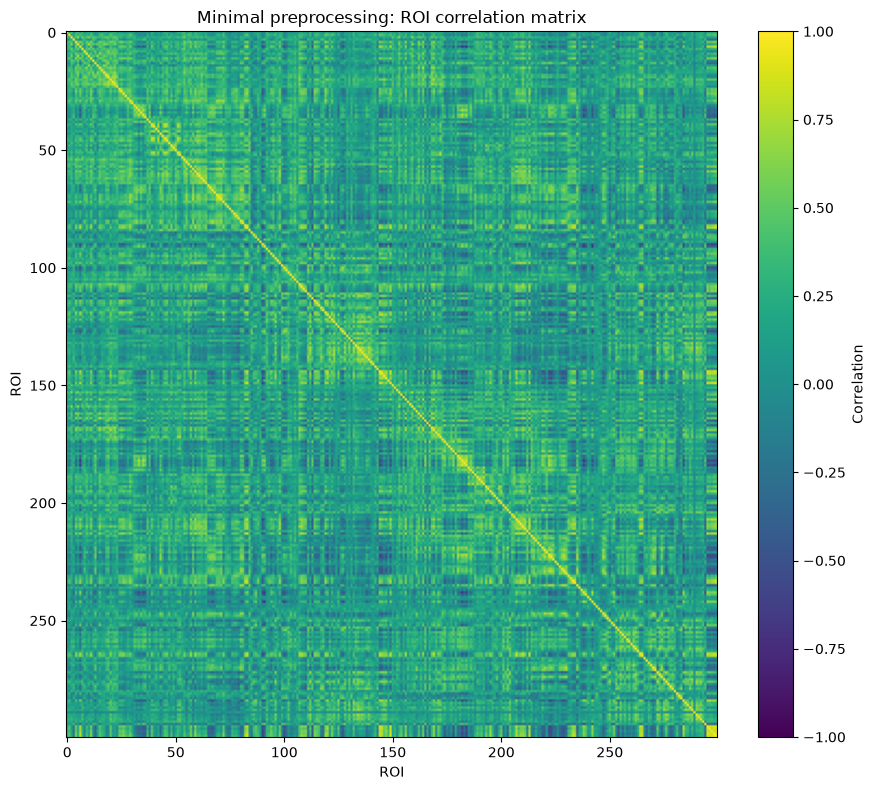

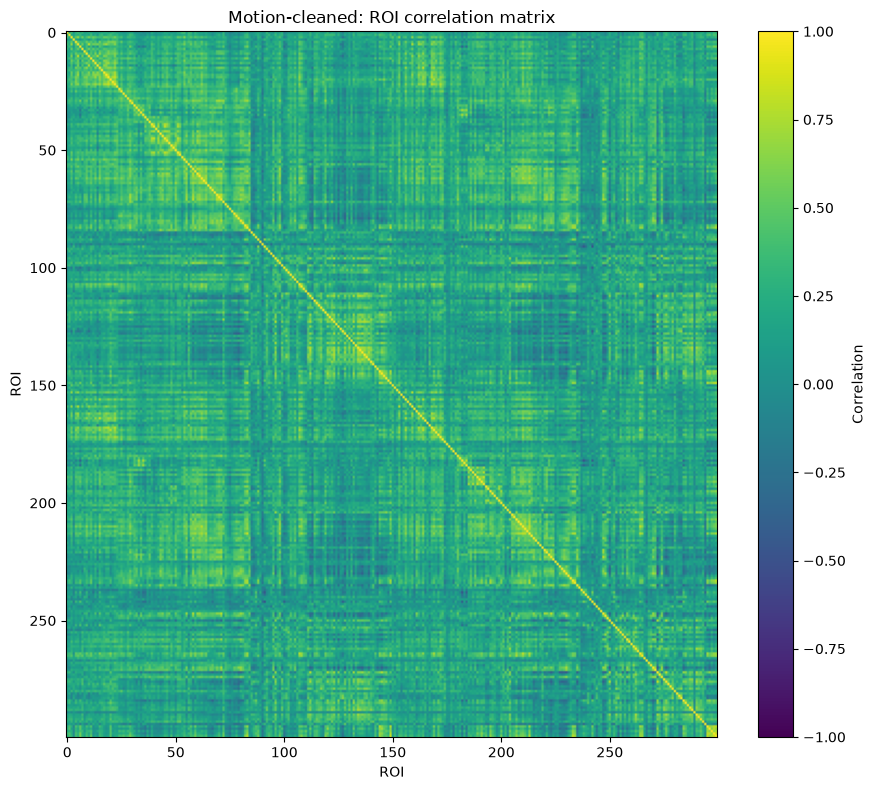

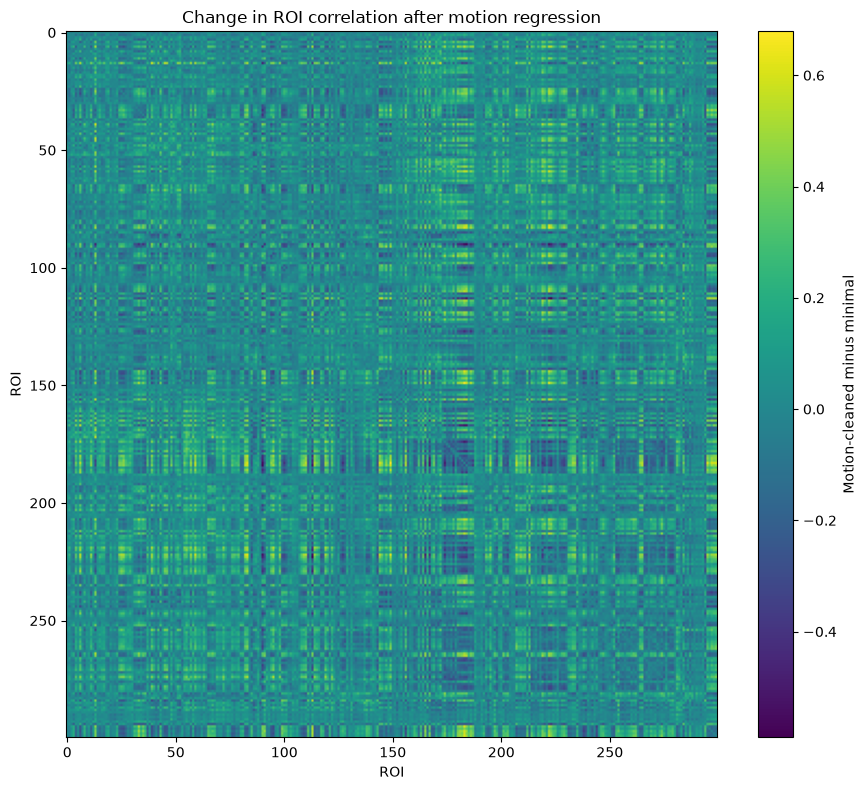

In [16]:
minimal_correlation = np.corrcoef(roi_timeseries_minimal.T)
motion_cleaned_correlation = np.corrcoef(roi_timeseries_motion_cleaned.T)
correlation_difference = motion_cleaned_correlation - minimal_correlation

plt.figure(figsize=(9, 8))
plt.imshow(minimal_correlation, aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.title("Minimal preprocessing: ROI correlation matrix")
plt.xlabel("ROI")
plt.ylabel("ROI")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 8))
plt.imshow(motion_cleaned_correlation, aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.title("Motion-cleaned: ROI correlation matrix")
plt.xlabel("ROI")
plt.ylabel("ROI")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 8))
plt.imshow(correlation_difference, aspect="auto")
plt.colorbar(label="Motion-cleaned minus minimal")
plt.title("Change in ROI correlation after motion regression")
plt.xlabel("ROI")
plt.ylabel("ROI")
plt.tight_layout()
plt.show()

## 15. Quantify the effect of motion regression

In [17]:
difference = roi_timeseries_motion_cleaned - roi_timeseries_minimal
per_roi_rmse = np.sqrt(np.mean(difference**2, axis=0))
per_roi_signal_correlation = np.array([
    np.corrcoef(
        roi_timeseries_minimal[:, roi_index],
        roi_timeseries_motion_cleaned[:, roi_index],
    )[0, 1]
    for roi_index in range(ATLAS_N_ROIS)
])

comparison_summary = {
    "mean_absolute_difference": float(np.mean(np.abs(difference))),
    "mean_per_roi_rmse": float(per_roi_rmse.mean()),
    "minimum_roi_signal_correlation": float(np.nanmin(per_roi_signal_correlation)),
    "mean_roi_signal_correlation": float(np.nanmean(per_roi_signal_correlation)),
    "maximum_roi_signal_correlation": float(np.nanmax(per_roi_signal_correlation)),
}
comparison_summary

{'mean_absolute_difference': 0.4386625289916992,
 'mean_per_roi_rmse': 0.5467661023139954,
 'minimum_roi_signal_correlation': 0.5458307064675948,
 'mean_roi_signal_correlation': 0.8394145057317951,
 'maximum_roi_signal_correlation': 0.9784903496496025}

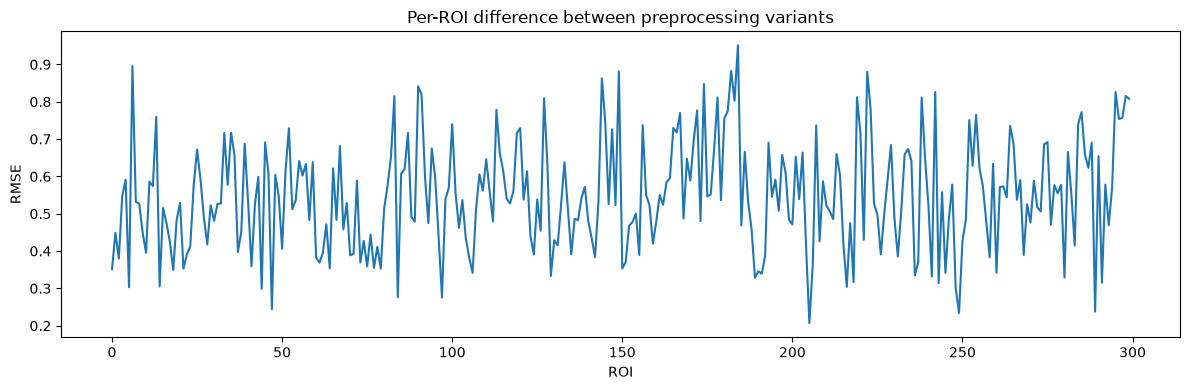

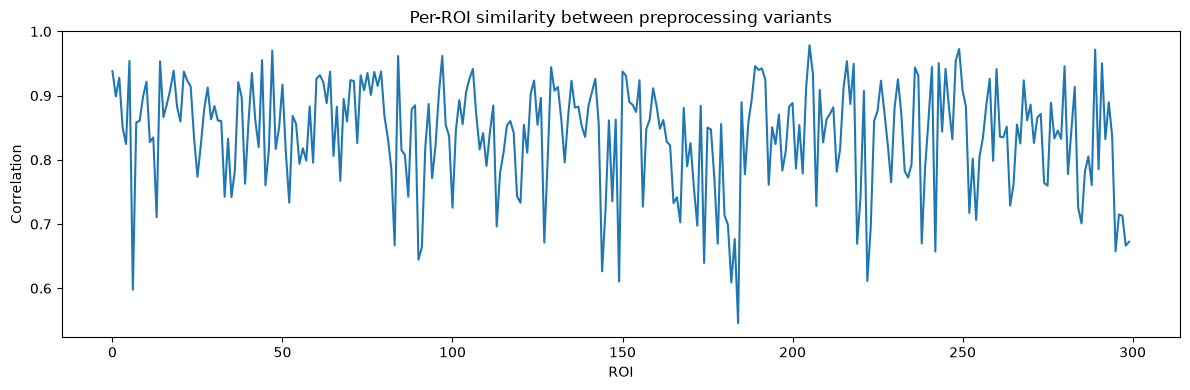

In [18]:
plt.figure(figsize=(12, 4))
plt.plot(per_roi_rmse)
plt.xlabel("ROI")
plt.ylabel("RMSE")
plt.title("Per-ROI difference between preprocessing variants")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(per_roi_signal_correlation)
plt.xlabel("ROI")
plt.ylabel("Correlation")
plt.title("Per-ROI similarity between preprocessing variants")
plt.tight_layout()
plt.show()

## 16. Save ROI labels

In [19]:
roi_labels_df = pd.DataFrame({
    "roi_index": np.arange(ATLAS_N_ROIS),
    "roi_label": roi_labels,
})
roi_labels_path = output_dir / "roi_labels.tsv"
roi_labels_df.to_csv(roi_labels_path, sep="\t", index=False)
print("Saved:", roi_labels_path)
roi_labels_df.head()

Saved: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/processed/hcp_ya_s1200/roi_timeseries/sub-100307/tfMRI_MOTOR_LR/roi_labels.tsv


,roi_index,roi_label
0,0,7Networks_LH_Vis_1
1,1,7Networks_LH_Vis_2
2,2,7Networks_LH_Vis_3
3,3,7Networks_LH_Vis_4
4,4,7Networks_LH_Vis_5


## 17. Save ROI arrays

In [20]:
minimal_npy_path = output_dir / "roi_timeseries_minimal.npy"
motion_cleaned_npy_path = output_dir / "roi_timeseries_motion_cleaned.npy"

np.save(minimal_npy_path, roi_timeseries_minimal.astype(np.float32))
np.save(motion_cleaned_npy_path, roi_timeseries_motion_cleaned.astype(np.float32))

print("Saved:", minimal_npy_path)
print("Saved:", motion_cleaned_npy_path)

Saved: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/processed/hcp_ya_s1200/roi_timeseries/sub-100307/tfMRI_MOTOR_LR/roi_timeseries_minimal.npy
Saved: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/processed/hcp_ya_s1200/roi_timeseries/sub-100307/tfMRI_MOTOR_LR/roi_timeseries_motion_cleaned.npy


## 18. Save tabular ROI time series

In [21]:
minimal_tsv_path = output_dir / "roi_timeseries_minimal.tsv"
motion_cleaned_tsv_path = output_dir / "roi_timeseries_motion_cleaned.tsv"

pd.DataFrame(roi_timeseries_minimal, columns=roi_labels).to_csv(
    minimal_tsv_path, sep="\t", index=False
)
pd.DataFrame(roi_timeseries_motion_cleaned, columns=roi_labels).to_csv(
    motion_cleaned_tsv_path, sep="\t", index=False
)

print("Saved:", minimal_tsv_path)
print("Saved:", motion_cleaned_tsv_path)

Saved: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/processed/hcp_ya_s1200/roi_timeseries/sub-100307/tfMRI_MOTOR_LR/roi_timeseries_minimal.tsv
Saved: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/processed/hcp_ya_s1200/roi_timeseries/sub-100307/tfMRI_MOTOR_LR/roi_timeseries_motion_cleaned.tsv


## 19. Save motion regressors

In [22]:
movement_npy_path = output_dir / "movement_regressors.npy"
movement_tsv_path = output_dir / "movement_regressors.tsv"

np.save(movement_npy_path, movement.astype(np.float32))
pd.DataFrame(
    movement,
    columns=[f"motion_regressor_{i:02d}" for i in range(movement.shape[1])],
).to_csv(movement_tsv_path, sep="\t", index=False)

print("Saved:", movement_npy_path)
print("Saved:", movement_tsv_path)

Saved: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/processed/hcp_ya_s1200/roi_timeseries/sub-100307/tfMRI_MOTOR_LR/movement_regressors.npy
Saved: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/processed/hcp_ya_s1200/roi_timeseries/sub-100307/tfMRI_MOTOR_LR/movement_regressors.tsv


## 20. Save metadata and QC summary

In [23]:
metadata = {
    "dataset_release": DATASET_RELEASE,
    "subject_id": SUBJECT_ID,
    "task": TASK,
    "run": RUN,
    "run_name": run_name,
    "source_nifti": str(func_path.relative_to(PROJECT_ROOT)),
    "movement_regressors_source": str(movement_path.relative_to(PROJECT_ROOT)),
    "events_directory": str(events_dir.relative_to(PROJECT_ROOT)) if events_dir.exists() else None,
    "atlas": {
        "name": "Schaefer2018",
        "n_rois": ATLAS_N_ROIS,
        "yeo_networks": ATLAS_NETWORKS,
        "resolution_mm": ATLAS_RESOLUTION_MM,
        "atlas_path": str(atlas_path),
    },
    "nifti": nifti_qc,
    "preprocessing": {
        "detrend": DETREND,
        "standardize": STANDARDIZE,
        "standardize_confounds": STANDARDIZE_CONFOUNDS,
        "low_pass_hz": LOW_PASS_HZ,
        "high_pass_hz": HIGH_PASS_HZ,
        "minimal_variant": {"confounds": None},
        "motion_cleaned_variant": {
            "confounds": "Movement_Regressors.txt",
            "n_confounds": int(movement.shape[1]),
        },
    },
    "outputs": {
        "roi_labels": str(roi_labels_path.relative_to(PROJECT_ROOT)),
        "minimal_npy": str(minimal_npy_path.relative_to(PROJECT_ROOT)),
        "motion_cleaned_npy": str(motion_cleaned_npy_path.relative_to(PROJECT_ROOT)),
        "movement_npy": str(movement_npy_path.relative_to(PROJECT_ROOT)),
    },
    "qc": {
        "minimal": minimal_qc,
        "motion_cleaned": motion_cleaned_qc,
        "comparison": comparison_summary,
    },
}
metadata_path = output_dir / "metadata.json"
metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")
print("Saved:", metadata_path)

Saved: /Users/srinivasgovindasurampudi/Projects/neurolens-rag/data/processed/hcp_ya_s1200/roi_timeseries/sub-100307/tfMRI_MOTOR_LR/metadata.json


## 21. Reload verification

In [24]:
reloaded_minimal = np.load(minimal_npy_path)
reloaded_motion_cleaned = np.load(motion_cleaned_npy_path)
reloaded_metadata = json.loads(metadata_path.read_text(encoding="utf-8"))

assert reloaded_minimal.shape == (n_timepoints, ATLAS_N_ROIS)
assert reloaded_motion_cleaned.shape == (n_timepoints, ATLAS_N_ROIS)
assert np.isfinite(reloaded_minimal).all()
assert np.isfinite(reloaded_motion_cleaned).all()

print("Reload verification passed.")
print("Minimal:", reloaded_minimal.shape, reloaded_minimal.dtype)
print("Motion-cleaned:", reloaded_motion_cleaned.shape, reloaded_motion_cleaned.dtype)
print("Metadata:", reloaded_metadata["subject_id"], reloaded_metadata["run_name"])

Reload verification passed.
Minimal: (284, 300) float32
Motion-cleaned: (284, 300) float32
Metadata: 100307 tfMRI_MOTOR_LR


## 22. Output inventory

In [25]:
output_inventory = []
for path in sorted(output_dir.iterdir()):
    if path.is_file():
        output_inventory.append({
            "filename": path.name,
            "size_mb": path.stat().st_size / (1024**2),
        })
pd.DataFrame(output_inventory)

,filename,size_mb
0,metadata.json,0.002766
1,movement_regressors.npy,0.013123
2,movement_regressors.tsv,0.028859
3,roi_labels.tsv,0.008630
4,roi_timeseries_minimal.npy,0.325134
5,roi_timeseries_minimal.tsv,0.894331
6,roi_timeseries_motion_cleaned.npy,0.325134
7,roi_timeseries_motion_cleaned.tsv,0.894643


## Next notebook

```text
04_hcp_events_and_targets.ipynb
```

It will inspect HCP event files, convert onset-duration information into volume-level representations, account for hemodynamic delay, define candidate targets, and save aligned `X`, `y`, masks, and run metadata.

Before scaling, verify that both arrays have shape `timepoints × 300`, no ROIs have zero variance, QC plots look plausible, and reload verification passes.
